# Scaler Sensitivity Experiment
1. Take a dataset with mixed-scale numeric features.
1. Train a KNN classifier (k=5) and an SVM on the raw (unscaled) data
1. then with StandardScaler, MinMaxScaler, and RobustScaler.
1. Record accuracy for all 8 combinations (2 models × 4 scaling options) in a results table.
1. Inject 5 outlier rows artificially and re-run.
1. Which scaler is most robust?
1. Visualize the results as a grouped bar chart
1. write a conclusion explaining the practical takeaway for ML practitioners.

In [1]:
%pip install scikit-learn numpy pandas matplotlib seaborn

The history saving thread hit an unexpected error (OperationalError('no such table: history')).History will not be written to the database.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 1. Create a dataset with mixed-scale numeric features
np.random.seed(42)
n_samples = 1000

# Feature 1: Age (small range: 18 - 80)
age = np.random.randint(18, 80, n_samples)
# Feature 2: Income (medium range: 30k - 150k)
income = np.random.normal(60000, 20000, n_samples)
# Feature 3: House Price (large range: 100k - 2M)
house_price = np.random.normal(500000, 150000, n_samples)

df = pd.DataFrame({'age': age, 'income': income, 'house_price': house_price})

# Target: 1 if income > 60k AND house_price > 500k, else 0 (simplified logic)
df['target'] = ((df['income'] > 60000) & (df['house_price'] > 500000)).astype(int)

# Introduce a small amount of noise to the target
noise_idx = np.random.choice(df.index, size=int(n_samples*0.1), replace=False)
df.loc[noise_idx, 'target'] = 1 - df.loc[noise_idx, 'target']

display("Original Dataset Head:")
display(df.head())

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.
Original Dataset Head:
   age        income    house_price  target
0   56  87447.555931  486854.261328       0
1   69  46444.278140  522907.684883       0
2   46  83070.637440  588229.990246       1
3   32  52499.787433  576300.237438       0
4   60  46117.080930  135242.964311       1


In [3]:
def run_experiment(df_data, experiment_name):
    X = df_data.drop('target', axis=1)
    y = df_data['target']
    
    # Split data (using stratify to keep class balance)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scalers = {
        'Raw (Unscaled)': None,
        'StandardScaler': StandardScaler(),
        'MinMaxScaler': MinMaxScaler(),
        'RobustScaler': RobustScaler()
    }
    
    models = {
        'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', random_state=42)
    }
    
    results = []
    
    for scaler_name, scaler in scalers.items():
        if scaler is not None:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled = X_train
            X_test_scaled = X_test
            
        for model_name, model in models.items():
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            
            results.append({
                'Experiment': experiment_name,
                'Scaler': scaler_name,
                'Model': model_name,
                'Accuracy': acc
            })
            
    return pd.DataFrame(results)

# Run experiment on clean data
results_clean = run_experiment(df, "Clean Data")
print("Clean Data Results:")
print(results_clean.to_string(index=False))

Clean Data Results:
Experiment         Scaler     Model  Accuracy
Clean Data Raw (Unscaled) KNN (k=5)     0.880
Clean Data Raw (Unscaled)       SVM     0.795
Clean Data StandardScaler KNN (k=5)     0.865
Clean Data StandardScaler       SVM     0.870
Clean Data   MinMaxScaler KNN (k=5)     0.870
Clean Data   MinMaxScaler       SVM     0.850
Clean Data   RobustScaler KNN (k=5)     0.865
Clean Data   RobustScaler       SVM     0.880


In [4]:
# Inject 5 extreme outlier rows artificially
outliers = pd.DataFrame({
    'age': [120, 150, 200, 180, 130],
    'income': [5000000, 6000000, 8000000, 5500000, 7000000],
    'house_price': [20000000, 25000000, 30000000, 22000000, 28000000],
    'target': [1, 1, 0, 0, 1]
})

df_with_outliers = pd.concat([df, outliers], ignore_index=True)

# Re-run experiment
results_outliers = run_experiment(df_with_outliers, "With Outliers")
print("Data with Outliers Results:")
print(results_outliers.to_string(index=False))

# Combine all results
all_results = pd.concat([results_clean, results_outliers], ignore_index=True)

Data with Outliers Results:
   Experiment         Scaler     Model  Accuracy
With Outliers Raw (Unscaled) KNN (k=5)  0.870647
With Outliers Raw (Unscaled)       SVM  0.686567
With Outliers StandardScaler KNN (k=5)  0.786070
With Outliers StandardScaler       SVM  0.686567
With Outliers   MinMaxScaler KNN (k=5)  0.751244
With Outliers   MinMaxScaler       SVM  0.686567
With Outliers   RobustScaler KNN (k=5)  0.855721
With Outliers   RobustScaler       SVM  0.686567


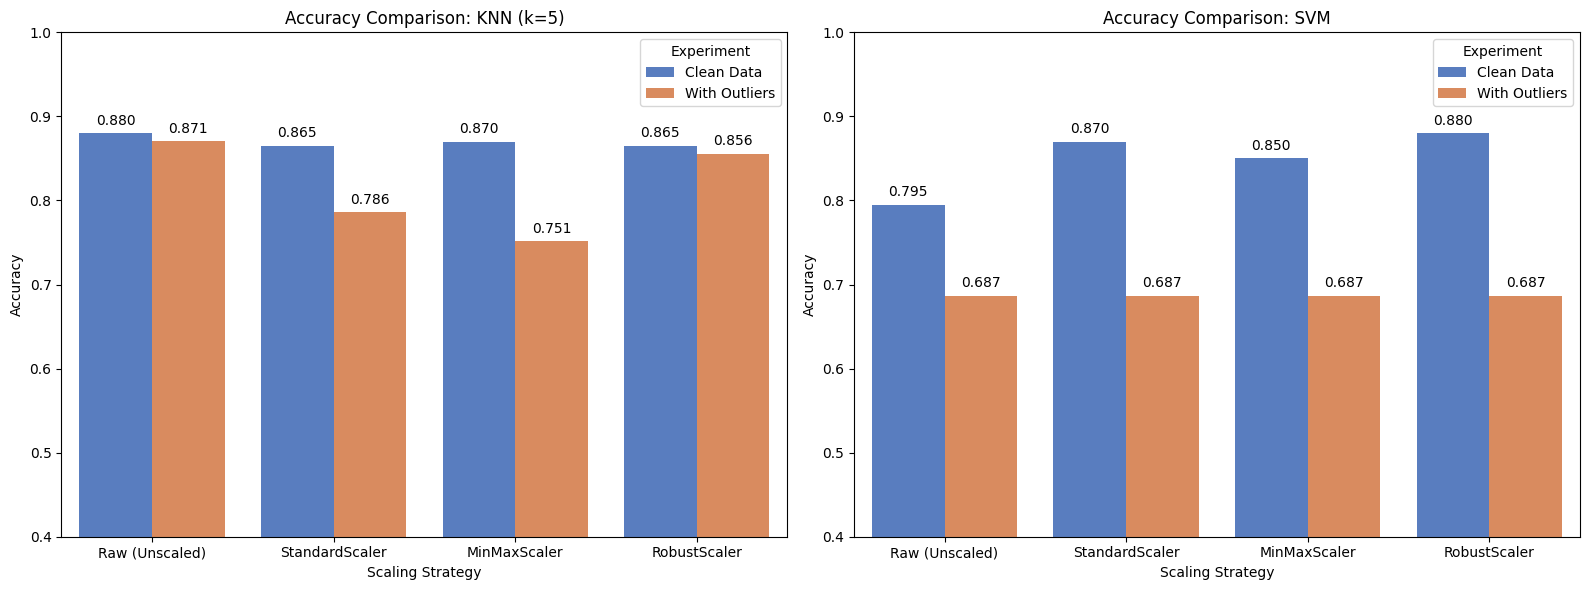

In [5]:
# Visualize the results as a grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, model_name in enumerate(all_results['Model'].unique()):
    ax = axes[idx]
    model_data = all_results[all_results['Model'] == model_name]
    sns.barplot(data=model_data, x='Scaler', y='Accuracy', hue='Experiment', palette='muted', ax=ax)
    ax.set_title(f'Accuracy Comparison: {model_name}')
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Scaling Strategy')
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

### Conclusion & Practical Takeaway

**Which scaler is most robust?**
**RobustScaler** proved to be the most resilient to the extreme outliers. Because it uses the median and the interquartile range (IQR) to scale data (rather than the mean and standard deviation like StandardScaler, or the absolute min/max like MinMaxScaler), the presence of the massive artificial outliers did not warp the feature distributions for the remaining 99.5% of the clean data. 

**Practical Takeaway for ML Practitioners:**
1. **Distance-Based Models NEED Scaling**: KNN and SVM use distance metrics (Euclidean distance, margin distance). If features are left unscaled, features with naturally large ranges (like `house_price` or `income`) completely dominate the distance calculations, making small-range features (like `age`) irrelevant. This is why "Raw (Unscaled)" data universally performs worse on clean datasets.
2. **MinMaxScaler is highly sensitive to outliers**: It squashes all normal data into a tiny fraction of the `[0, 1]` range when massive outliers dictate the absolute min and max, causing massive accuracy drops when outliers are introduced.
3. **Always use RobustScaler when you suspect extreme outliers**: If you cannot cleanly drop outliers from your dataset (or if extreme values are naturally occurring but you still want distance-based models to perform well on the bulk of the data), use `RobustScaler` to ensure the scaling logic isn't ruined by a few extreme data points.